<a href="https://colab.research.google.com/github/SamShinwari/Advanced-AI-Bootcamp-2026/blob/main/Project_6_Named_Entity_Recognition_(NER).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project 6: Named Entity Recognition (NER)**

## Objective

In this project, you'll learn how to extract **real-world entities** from news articles.

For example:

> **Sentence:**
>
> *Ukraine President Volodymyr Zelensky met Boris Johnson in Kyiv.*

NER identifies:

| Word               | Entity        |
| ------------------ | ------------- |
| Ukraine            | Country (GPE) |
| Volodymyr Zelensky | Person        |
| Boris Johnson      | Person        |
| Kyiv               | City (GPE)    |

---

# Why NER?

Named Entity Recognition is used in:

* Search Engines
* Google News
* ChatGPT
* Question Answering
* Information Extraction
* Knowledge Graphs
* Recommendation Systems

---

# Step 1: Install spaCy

In [93]:
pip install spacy

In [94]:
import nltk

Download the English model:

In [95]:
# Download required resources (run once)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

---

# Step 2: Import Libraries

In [96]:
import pandas as pd
import spacy
from google.colab import drive

In [97]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---

# Step 3: Load the English Model

In [98]:
nlp = spacy.load("en_core_web_sm")
# Download required resources (run once)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

---

# Step 4: Load Dataset

In [99]:
file_path = '/content/drive/MyDrive/Colab Notebooks/bbc_dataset.csv'
df = pd.read_csv(file_path)
df.head()

,title,pubDate,guid,link,description
0,Ukraine: Angry Zelensky vows to punish Russian...,"Mon, 07 Mar 2022 08:01:56 GMT",https://www.bbc.co.uk/news/world-europe-60638042,https://www.bbc.co.uk/news/world-europe-606380...,The Ukrainian president says the country will ...
1,War in Ukraine: Taking cover in a town under a...,"Sun, 06 Mar 2022 22:49:58 GMT",https://www.bbc.co.uk/news/world-europe-60641873,https://www.bbc.co.uk/news/world-europe-606418...,"Jeremy Bowen was on the frontline in Irpin, as..."
2,Ukraine war 'catastrophic for global food',"Mon, 07 Mar 2022 00:14:42 GMT",https://www.bbc.co.uk/news/business-60623941,https://www.bbc.co.uk/news/business-60623941?a...,One of the world's biggest fertiliser firms sa...
3,Manchester Arena bombing: Saffie Roussos's par...,"Mon, 07 Mar 2022 00:05:40 GMT",https://www.bbc.co.uk/news/uk-60579079,https://www.bbc.co.uk/news/uk-60579079?at_medi...,The parents of the Manchester Arena bombing's ...
4,Ukraine conflict: Oil price soars to highest l...,"Mon, 07 Mar 2022 08:15:53 GMT",https://www.bbc.co.uk/news/business-60642786,https://www.bbc.co.uk/news/business-60642786?a...,Consumers are feeling the impact of higher ene...


In [100]:
df = df.dropna(subset=["description"])
df = df.drop_duplicates(subset=["description"])
df = df.reset_index(drop=True)

In [101]:
df = df.drop(columns=['guid', 'link','pubDate'])
df.head()

,title,description
0,Ukraine: Angry Zelensky vows to punish Russian...,The Ukrainian president says the country will ...
1,War in Ukraine: Taking cover in a town under a...,"Jeremy Bowen was on the frontline in Irpin, as..."
2,Ukraine war 'catastrophic for global food',One of the world's biggest fertiliser firms sa...
3,Manchester Arena bombing: Saffie Roussos's par...,The parents of the Manchester Arena bombing's ...
4,Ukraine conflict: Oil price soars to highest l...,Consumers are feeling the impact of higher ene...


---

# Step 5: Select a Sample News

In [102]:
text = df["description"].iloc[0]

print(text)

The Ukrainian president says the country will not forgive or forget those who murder its civilians.


Example

```text
The Ukrainian president says the country will not forgive or forget those who murder its civilians.
```

---

# Step 6: Process Text

In [103]:
doc = nlp(text)

---

# Step 7: Extract Named Entities

In [104]:
for entity in doc.ents:
    print(entity.text, "---->", entity.label_)

Ukrainian ----> NORP


In [105]:
text = "President Volodymyr Zelensky met Boris Johnson in Kyiv, Ukraine."

doc = nlp(text)

for ent in doc.ents:
    print(ent.text, ent.label_)

Volodymyr Zelensky PERSON
Boris Johnson PERSON
Kyiv GPE
Ukraine GPE


Example Output

```text
Ukrainian ----> NORP
```

Another Example

```python
text = "President Volodymyr Zelensky met Boris Johnson in Kyiv, Ukraine."

doc = nlp(text)

for ent in doc.ents:
    print(ent.text, ent.label_)
```

Output

```text
Volodymyr Zelensky PERSON
Boris Johnson PERSON
Kyiv GPE
Ukraine GPE
```

---

# Step 8: Store in DataFrame

In [106]:
entities = []

for ent in doc.ents:
    entities.append([ent.text, ent.label_])

entity_df = pd.DataFrame(
    entities,
    columns=["Entity", "Label"]
)

print(entity_df)

               Entity   Label
0  Volodymyr Zelensky  PERSON
1       Boris Johnson  PERSON
2                Kyiv     GPE
3             Ukraine     GPE


Output

| Entity   | Label  |
| -------- | ------ |
| Zelensky | PERSON |
| Kyiv     | GPE    |
| Ukraine  | GPE    |

---

# Step 9: Entity Labels

| Label       | Meaning                                 |
| ----------- | --------------------------------------- |
| PERSON      | Person Name                             |
| ORG         | Organization                            |
| GPE         | Country, City, State                    |
| LOC         | Location                                |
| NORP        | Nationality, Religious, Political Group |
| DATE        | Date                                    |
| TIME        | Time                                    |
| MONEY       | Money                                   |
| EVENT       | Event                                   |
| PRODUCT     | Product                                 |
| FAC         | Building/Facility                       |
| LAW         | Law                                     |
| WORK_OF_ART | Books, Songs, Movies                    |

---

# Step 10: Count Entity Types

In [107]:
entity_df["Label"].value_counts()

,count
Label,
PERSON,2
GPE,2


Example

```text
PERSON    15
GPE       12
ORG        9
DATE       8
NORP       6
```

---

# Step 11: Plot Entity Counts

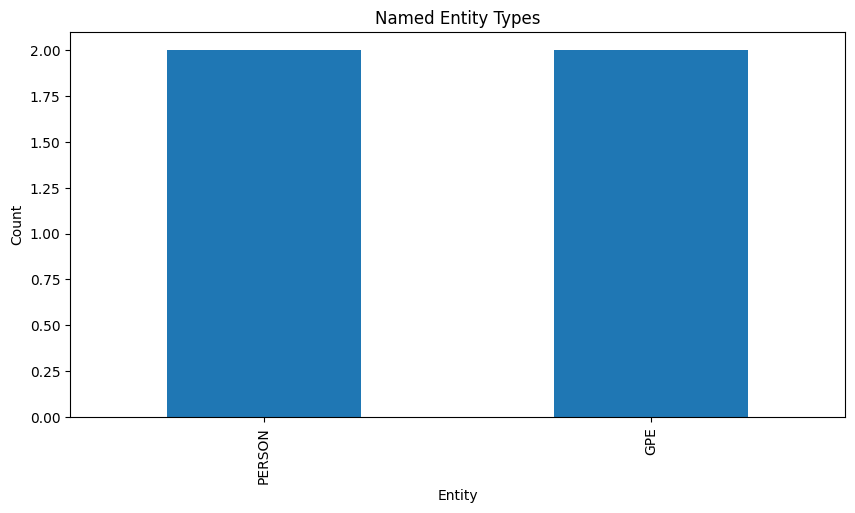

In [108]:
import matplotlib.pyplot as plt

entity_df["Label"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Named Entity Types")

plt.xlabel("Entity")

plt.ylabel("Count")

plt.show()

---

# Step 12: Extract Entities from Entire Dataset

In [109]:
def extract_entities(text):

    doc = nlp(str(text))

    return [(ent.text, ent.label_) for ent in doc.ents]


df["entities"] = df["description"].apply(extract_entities)

df.head()

,title,description,entities
0,Ukraine: Angry Zelensky vows to punish Russian...,The Ukrainian president says the country will ...,"[(Ukrainian, NORP)]"
1,War in Ukraine: Taking cover in a town under a...,"Jeremy Bowen was on the frontline in Irpin, as...","[(Jeremy Bowen, PERSON), (Irpin, GPE), (Russia..."
2,Ukraine war 'catastrophic for global food',One of the world's biggest fertiliser firms sa...,"[(One, CARDINAL)]"
3,Manchester Arena bombing: Saffie Roussos's par...,The parents of the Manchester Arena bombing's ...,"[(Manchester Arena, PERSON)]"
4,Ukraine conflict: Oil price soars to highest l...,Consumers are feeling the impact of higher ene...,[]


Example Output

| Description    | Entities                        |
| -------------- | ------------------------------- |
| Ukraine war... | [(Ukraine, GPE), (Russia, GPE)] |

---

# Step 13: Count All Entities

In [110]:
from collections import Counter

entity_counter = Counter()

for entity_list in df["entities"]:

    for entity, label in entity_list:

        entity_counter[(entity, label)] += 1

print(entity_counter.most_common(20))

[(('England', 'GPE'), 1621), (('first', 'ORDINAL'), 1441), (('BBC', 'ORG'), 1290), (('UK', 'GPE'), 1199), (('US', 'GPE'), 849), (('Ukraine', 'GPE'), 839), (('two', 'CARDINAL'), 654), (('one', 'CARDINAL'), 604), (('Russia', 'GPE'), 580), (('Russian', 'NORP'), 518), (('London', 'GPE'), 399), (('second', 'ORDINAL'), 391), (('World Cup', 'EVENT'), 385), (('Saturday', 'DATE'), 351), (('three', 'CARDINAL'), 351), (('British', 'NORP'), 351), (('Scotland', 'GPE'), 329), (('Sunday', 'DATE'), 325), (('Israel', 'GPE'), 325), (('Manchester City', 'GPE'), 312)]


Example

```text
Ukraine     GPE      420

Russia      GPE      380

Covid       EVENT    250

Boris       PERSON    95
```

---

# Step 14: Separate Persons

In [111]:
persons = []

for entity_list in df["entities"]:

    for entity, label in entity_list:

        if label == "PERSON":

            persons.append(entity)

print(persons[:20])

['Jeremy Bowen', 'Manchester Arena', 'Boris Johnson', 'Vladivostok', 'Ivan Kuliak', 'Mykhailo Fedorov', 'Kevin Connolly', 'Valeri', 'Lynette Lee', 'Covid', 'Putin', 'Jeremy Bowen', 'Putin', 'Welsh', 'Manchester United', 'Ollie Robinson', 'Joe Perry', 'Menna Fitzpatrick', 'Neil Simpson', 'Danny Murphy']


---

# Step 15: Separate Countries and Cities

In [112]:
locations = []

for entity_list in df["entities"]:

    for entity, label in entity_list:

        if label == "GPE":

            locations.append(entity)

print(locations[:20])

['Irpin', 'Netflix', 'St Petersburg', 'Ukrainian', 'Qatar', 'Taiwan', 'Przemysl', 'Ukraine', 'Russia', 'Russia', 'Ukraine', 'US', 'Ukraine', 'Ukrainian', 'Russia', 'Ukraine', 'Russia', 'Ukraine', 'Ukraine', 'Russia']


---

# Step 16: Separate Organizations

In [113]:
organizations = []

for entity_list in df["entities"]:

    for entity, label in entity_list:

        if label == "ORG":

            organizations.append(entity)

print(organizations[:20])

['TikTok', 'Maxim', 'BBC', 'Mariupol', 'Lesya', 'Zeebrugge', "Queen's", 'BBC News', 'Trimontium', 'Borders', 'BBC', 'BBC', 'the Beijing Winter Paralympics', 'Peterhead', 'Njord', 'Sumy', 'Peterhead', 'Njord', 'Lesya', "the Women's World Cup"]


---

# Step 17: Save Dataset

In [114]:
df.to_csv(
    "news_with_entities.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


---

# Complete Code

---

# Sample Output

| Entity        | Label  |
| ------------- | ------ |
| Ukraine       | GPE    |
| Russia        | GPE    |
| Boris Johnson | PERSON |
| Zelensky      | PERSON |
| BBC           | ORG    |
| Netflix       | ORG    |
| Scotland      | GPE    |
| Covid         | EVENT  |

---

# What You'll Learn

By completing this project, you'll understand:

* How spaCy performs Named Entity Recognition (NER).
* The most common entity labels (`PERSON`, `ORG`, `GPE`, `DATE`, etc.).
* How to extract people, organizations, and locations from news articles.
* How to count and analyze entity frequencies across a dataset.
* How to prepare structured entity data for downstream tasks.

---

# Real-World Applications

* **Google News:** Highlight people, organizations, and locations.
* **Search Engines:** Improve search relevance using entities.
* **Knowledge Graphs:** Build relationships between entities.
* **Question Answering:** Answer questions like "Who?", "Where?", and "When?".
* **Recommendation Systems:** Recommend articles about the same entities.
* **Trend Analysis:** Identify the most mentioned people, countries, or organizations over time.